
# Modelos Probabilísticos en PLN
## Práctica: N-gramas

Este notebook implementa un modelo de **2-gramas y 3-gramas** a partir del corpus `CorpusEducacion.txt`.  
Se realiza:
- Carga y limpieza del corpus.
- Tokenización y lematización.
- Eliminación de stopwords.
- Cálculo de frecuencias absolutas y relativas.
- Comparación en gráfico de barras entre 2-gramas y 3-gramas.
```

---


### 1. Importación de librerías

In [15]:

import nltk
import spacy
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt

# Descargar recursos necesarios
#nltk.download("punkt")
#nltk.download("stopwords")

# Cargar modelo de spaCy en español
nlp = spacy.load("es_core_news_sm")


---

### 2. Función para cargar el corpus

In [16]:
def cargar_corpus(ruta):
    with open(ruta, "r", encoding="latin-1") as f:
        texto = f.read()
    return texto


---

### 3. Preprocesamiento del texto

In [17]:

def preprocesar_texto(texto):
    doc = nlp(texto.lower())
    tokens = [token.lemma_ for token in doc 
              if token.is_alpha and token.lemma_ not in stopwords.words("spanish")]
    return tokens



---

### 4. Generación de N‑gramas

In [18]:
def generar_ngramas(tokens, n, min_df=2):
    ngramas = list(ngrams(tokens, n))
    contador = Counter(ngramas)
    # Filtrar por frecuencia mínima
    return {ng: freq for ng, freq in contador.items() if freq >= min_df}


---

### 5. Visualización

In [19]:

def graficar_ngramas(ngramas, titulo):
    elementos = list(ngramas.keys())
    frecuencias = list(ngramas.values())
    plt.figure(figsize=(10,5))
    plt.bar(range(len(elementos)), frecuencias, tick_label=[" ".join(e) for e in elementos])
    plt.xticks(rotation=45)
    plt.title(titulo)
    plt.show()




---

### 6. Ejecución principal

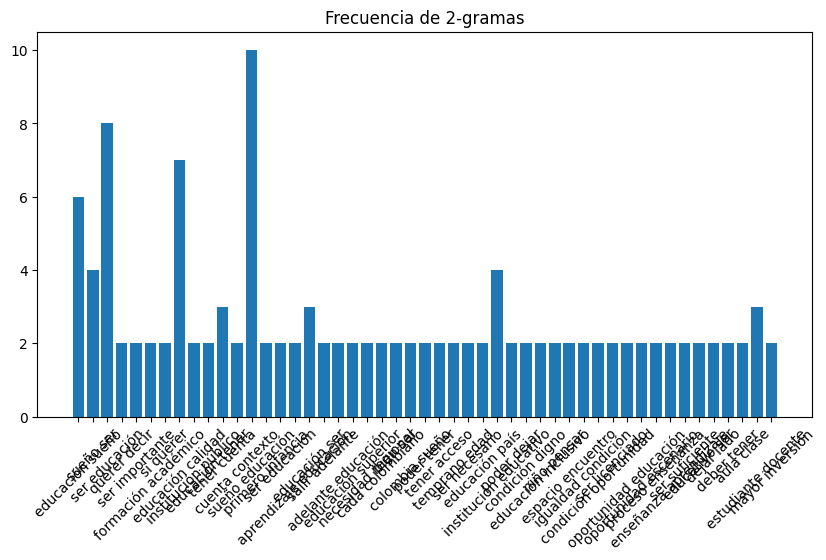

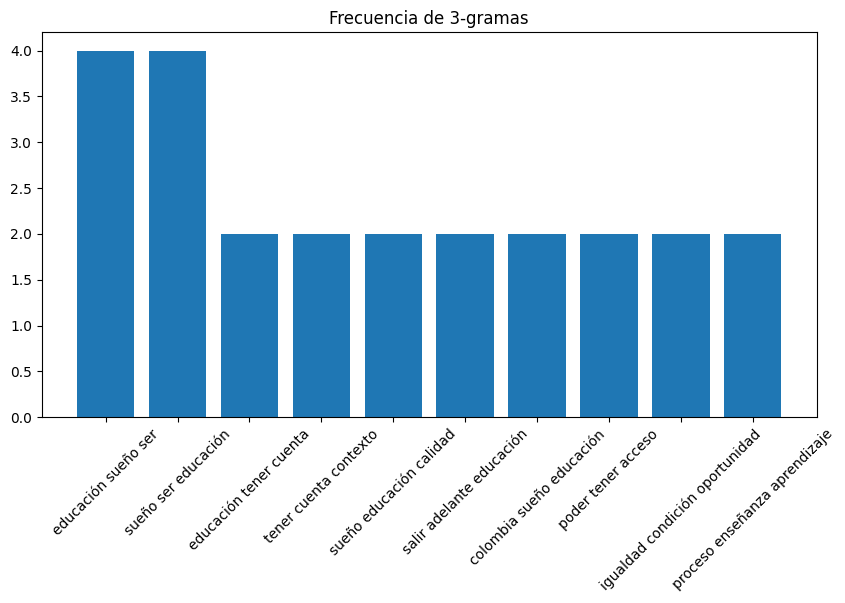

In [20]:
# Cargar corpus
texto = cargar_corpus("c:/Users/Benja/Downloads/python2/modelos_n_gramas/CorpusEducacion.txt")


# Preprocesar
tokens = preprocesar_texto(texto)

# Generar 2-gramas y 3-gramas
bigramas = generar_ngramas(tokens, 2, min_df=2)
trigramas = generar_ngramas(tokens, 3, min_df=2)

# Graficar
graficar_ngramas(bigramas, "Frecuencia de 2-gramas")
graficar_ngramas(trigramas, "Frecuencia de 3-gramas")
